In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_excel("/content/HousePrediction.xlsx")  # your dataset

In [3]:
print(df.columns)

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')


In [ ]:
df.head(100)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,60,RL,9765,Corner,1Fam,8,1993,1993,VinylSd,0.0,680.0,185000.0
96,96,20,RL,10264,Inside,1Fam,5,1999,1999,VinylSd,0.0,1588.0,214000.0
97,97,20,RL,10921,Inside,1Fam,5,1965,1965,HdBoard,0.0,960.0,94750.0
98,98,30,RL,10625,Corner,1Fam,5,1920,1950,Wd Sdng,0.0,458.0,83000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [ ]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1


In [ ]:
df['SalePrice'].isnull().sum()

np.int64(1459)

In [ ]:
df.shape #both train data and test data is mixed.1149 missing data is test data.

(2919, 13)

In [4]:
df_train = df[df['SalePrice'].notnull()]
df_test = df[df['SalePrice'].isnull()]

In [5]:
df_train.shape
df_test.shape

(1459, 13)

In [6]:
df[['Id', 'SalePrice']].head(20)

,Id,SalePrice
0,0,208500.0
1,1,181500.0
2,2,223500.0
3,3,140000.0
4,4,250000.0
5,5,143000.0
6,6,307000.0
7,7,200000.0
8,8,129900.0
9,9,118000.0


In [7]:
df_train.head()
df_test.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1460,1460,20,RH,11622,Inside,1Fam,6,1961,1961,VinylSd,144.0,882.0,NaN
1461,1461,20,RL,14267,Corner,1Fam,6,1958,1958,Wd Sdng,0.0,1329.0,NaN
1462,1462,60,RL,13830,Inside,1Fam,5,1997,1998,VinylSd,0.0,928.0,NaN
1463,1463,60,RL,9978,Inside,1Fam,6,1998,1998,VinylSd,0.0,926.0,NaN
1464,1464,120,RL,5005,Inside,TwnhsE,5,1992,1992,HdBoard,0.0,1280.0,NaN


In [8]:
df = df_train.copy()

In [9]:
# Categorical
df['MSZoning'].fillna(df['MSZoning'].mode()[0], inplace=True)
df['Exterior1st'].fillna(df['Exterior1st'].mode()[0], inplace=True)

# Numerical
df['BsmtFinSF2'].fillna(df['BsmtFinSF2'].median(), inplace=True)
df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].median(), inplace=True)

/tmp/ipykernel_820/337574518.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MSZoning'].fillna(df['MSZoning'].mode()[0], inplace=True)
/tmp/ipykernel_820/337574518.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [10]:
df['HouseAge'] = 2024 - df['YearBuilt']
df['RemodAge'] = 2024 - df['YearRemodAdd']

In [11]:
df = pd.get_dummies(df, drop_first=True)

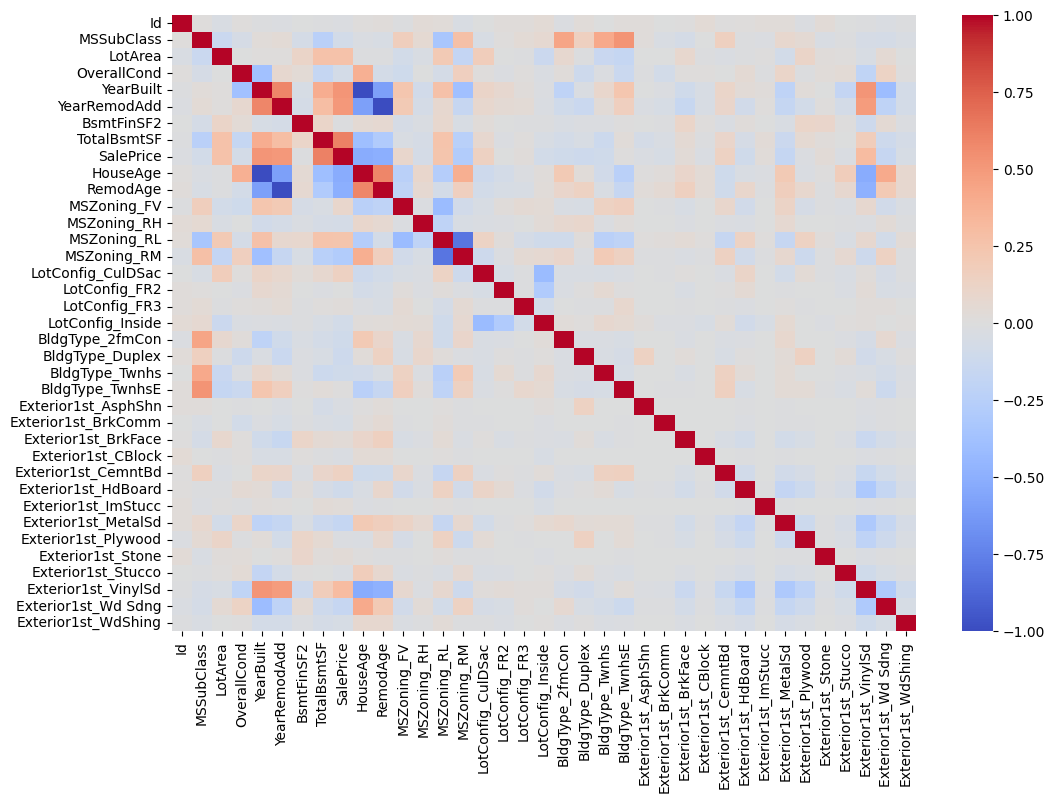

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [13]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_pred))
print("R2 Score:", r2_score(y_val, y_pred))

MAE: 32888.041328641775
R2 Score: 0.6204105751145546


In [17]:
df_test = df_test.copy()

# same missing value handling
df_test['MSZoning'].fillna(df_test['MSZoning'].mode()[0], inplace=True)
df_test['Exterior1st'].fillna(df_test['Exterior1st'].mode()[0], inplace=True)

df_test['BsmtFinSF2'].fillna(df_test['BsmtFinSF2'].median(), inplace=True)
df_test['TotalBsmtSF'].fillna(df_test['TotalBsmtSF'].median(), inplace=True)

# feature engineering
df_test['HouseAge'] = 2024 - df_test['YearBuilt']
df_test['RemodAge'] = 2024 - df_test['YearRemodAdd']

# encoding
df_test = pd.get_dummies(df_test, drop_first=True)

/tmp/ipykernel_820/2846424490.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['MSZoning'].fillna(df_test['MSZoning'].mode()[0], inplace=True)
/tmp/ipykernel_820/2846424490.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [18]:
df_test = df_test.reindex(columns=X.columns, fill_value=0)

In [ ]:
test_predictions = model.predict(df_test)

In [19]:
for col in ['MSZoning', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF']:
    print(col)
    print(df_train.groupby(df_train[col].isnull())['SalePrice'].mean())
    print("------")

MSZoning
MSZoning
False    180921.19589
Name: SalePrice, dtype: float64
------
Exterior1st
Exterior1st
False    180921.19589
Name: SalePrice, dtype: float64
------
BsmtFinSF2
BsmtFinSF2
False    180921.19589
Name: SalePrice, dtype: float64
------
TotalBsmtSF
TotalBsmtSF
False    180921.19589
Name: SalePrice, dtype: float64
------


In [20]:
num_features = df_train.select_dtypes(include=['int64','float64'])
print("Number of numerical features:", num_features.shape[1])

Number of numerical features: 9


In [21]:
num_features.head()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,8450,5,2003,2003,0.0,856.0,208500.0
1,1,20,9600,8,1976,1976,0.0,1262.0,181500.0
2,2,60,11250,5,2001,2002,0.0,920.0,223500.0
3,3,70,9550,5,1915,1970,0.0,756.0,140000.0
4,4,60,14260,5,2000,2000,0.0,1145.0,250000.0


<Axes: xlabel='HouseAge', ylabel='SalePrice'>

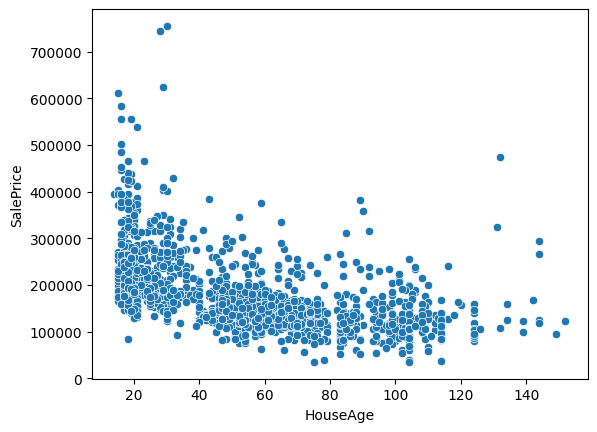

In [22]:
df_train['HouseAge'] = 2024 - df_train['YearBuilt']

import seaborn as sns
sns.scatterplot(x=df_train['HouseAge'], y=df_train['SalePrice'])

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

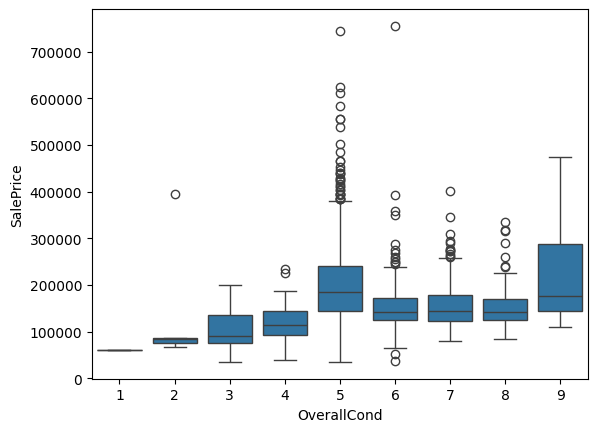

In [23]:
sns.boxplot(x=df_train['OverallCond'], y=df_train['SalePrice'])

<Axes: xlabel='LotArea', ylabel='SalePrice'>

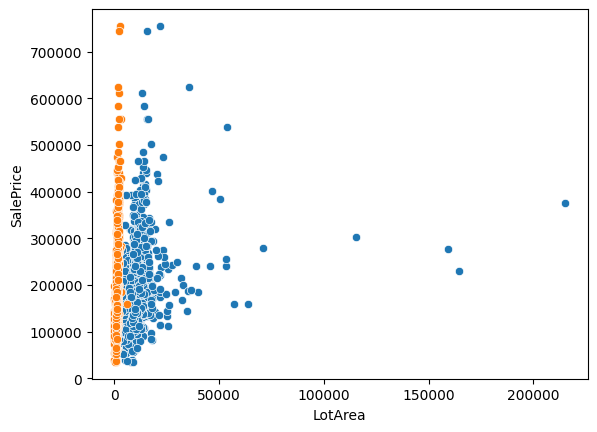

In [24]:
sns.scatterplot(x=df_train['LotArea'], y=df_train['SalePrice'])
sns.scatterplot(x=df_train['TotalBsmtSF'], y=df_train['SalePrice'])

<Axes: >

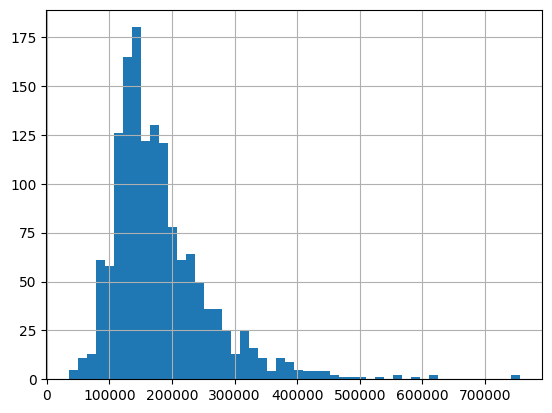

In [25]:
df_train['SalePrice'].hist(bins=50)

<Axes: >

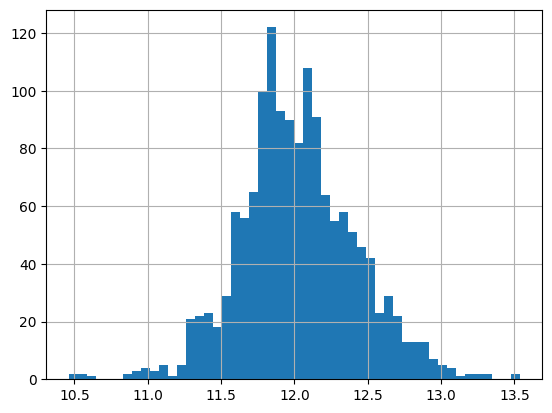

In [26]:
import numpy as np
df_train['SalePrice_log'] = np.log(df_train['SalePrice'])

df_train['SalePrice_log'].hist(bins=50)

<Axes: ylabel='SalePrice'>

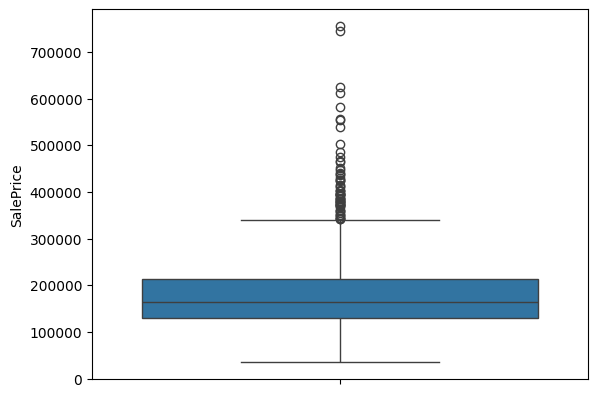

In [27]:
sns.boxplot(df_train['SalePrice'])

<Axes: xlabel='MSZoning'>

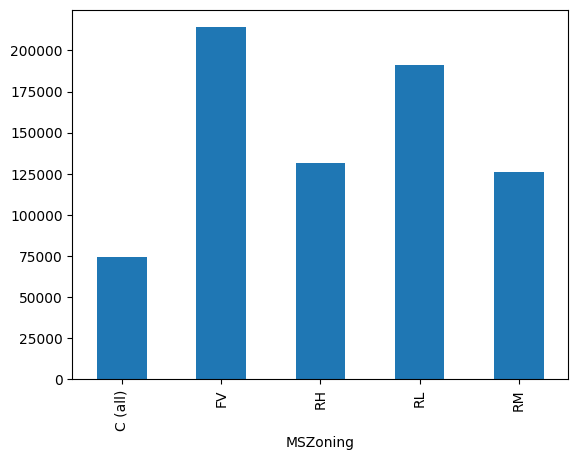

In [28]:
df_train.groupby('MSZoning')['SalePrice'].mean().plot(kind='bar')

<Axes: >

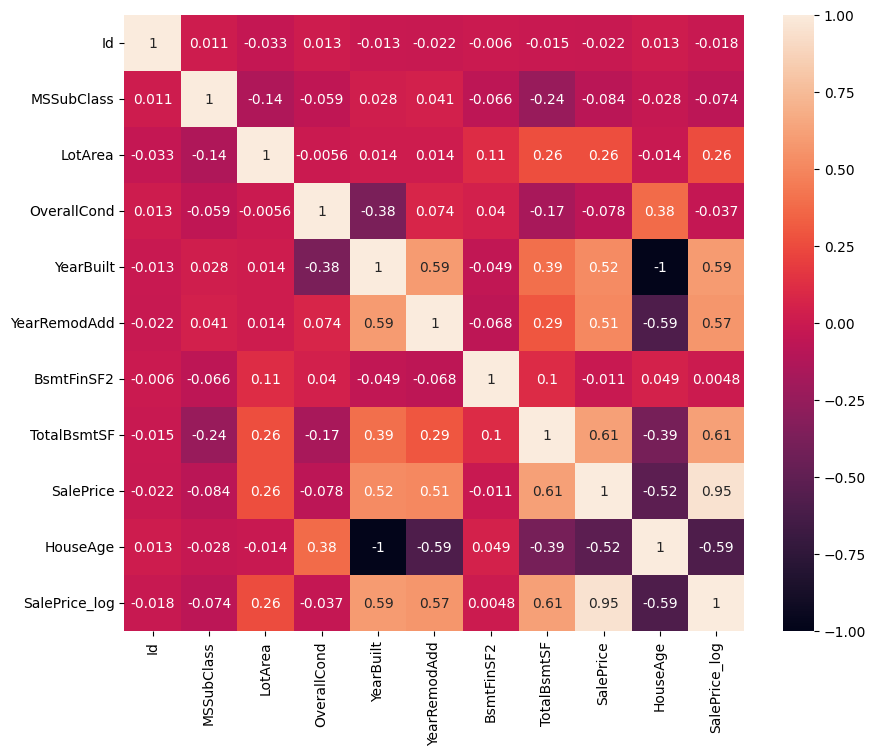

In [29]:
corr = df_train.corr(numeric_only=True)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)

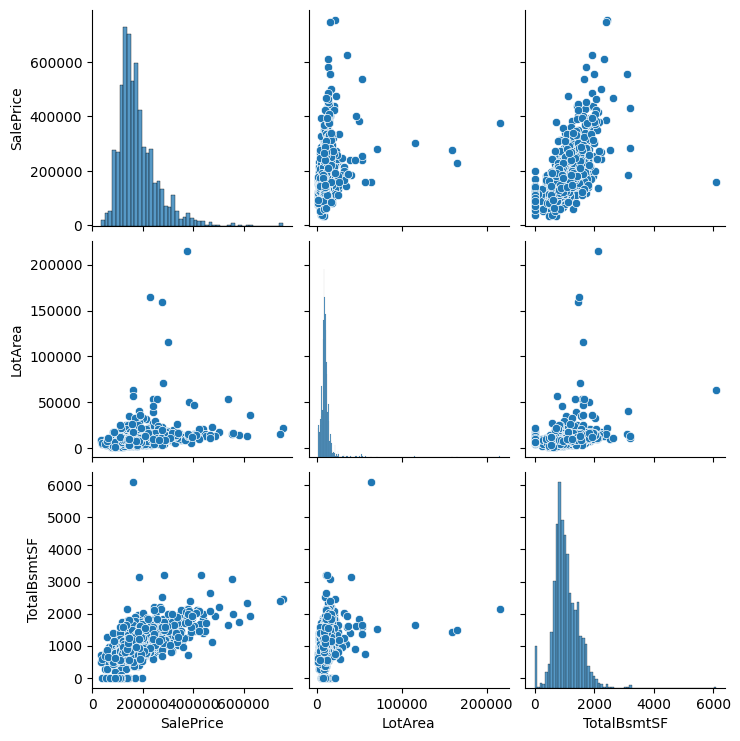

In [30]:
sns.pairplot(df_train[['SalePrice','LotArea','TotalBsmtSF']])

In [31]:
df_train.groupby('MSZoning')['SalePrice'].mean()

,SalePrice
MSZoning,
C (all),74528.000000
FV,214014.061538
RH,131558.375000
RL,191004.994787
RM,126316.830275


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

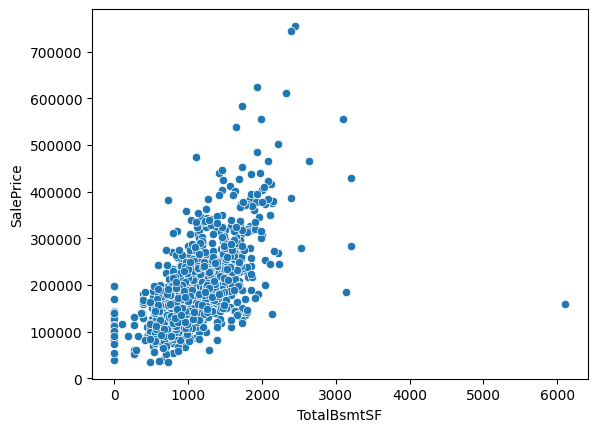

In [32]:
sns.scatterplot(x=df_train['TotalBsmtSF'], y=df_train['SalePrice'])

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

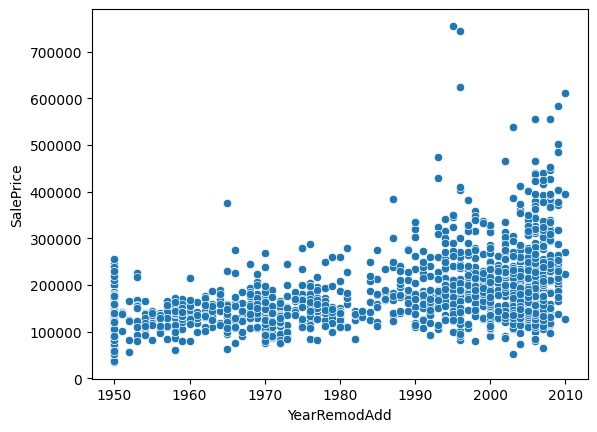

In [33]:
sns.scatterplot(x=df_train['YearRemodAdd'], y=df_train['SalePrice'])

In [35]:
cat_df = pd.get_dummies(df_train[['MSZoning','BldgType','Exterior1st']], drop_first=True)

X = cat_df
y = df_train['SalePrice']